# SHAP รายบุคคล (Puripat, wk4–5): ร่าง

ใช้โมเดลตัวทดลอง `attrition-xgboost-P` v1 จาก MLflow ในเครื่อง กับ test set (294 คน)
โมเดลสุดท้ายต้องรอเลือกร่วมกับ Saphondanai เมื่อได้แล้วแค่เปลี่ยน `MODEL_URI` ใน `src/shap_explain.py` แล้วรันใหม่ได้เลย

วิธีอ่านค่า SHAP: ค่าบวก = ปัจจัยนั้นดันให้เสี่ยงลาออกมากขึ้น, ค่าลบ = ดันให้อยู่ต่อ (หน่วยเป็น log-odds ไม่ใช่ %)

In [1]:
import sys
sys.path.append("../src")
import warnings
warnings.filterwarnings("ignore")
import matplotlib.pyplot as plt
import shap
from shap_explain import explain, load_model_and_test_data, mean_abs_shap, top_factors

model, X, y = load_model_and_test_data()
exp = explain(model, X)
print(X.shape, "| SHAP values:", exp.values.shape)

(294, 50) | SHAP values: (294, 50)


## 1. ภาพรวม: ปัจจัยไหนสำคัญที่สุด (ทั้ง test set)

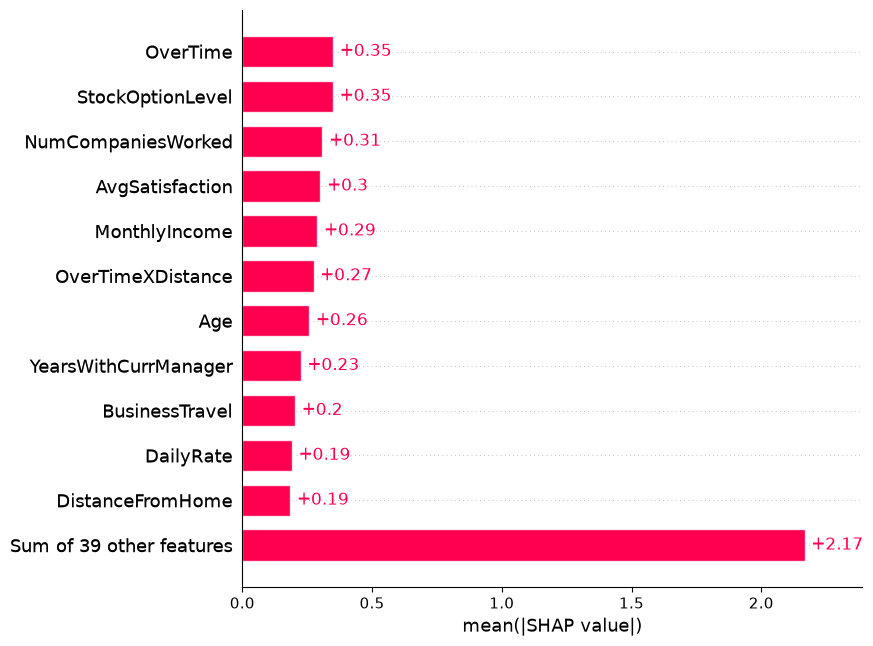

In [2]:
shap.plots.bar(exp, max_display=12)

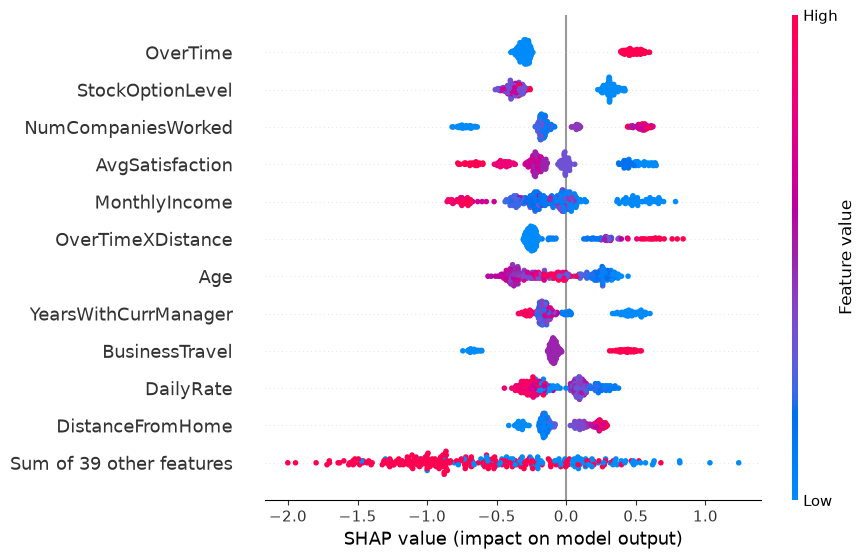

In [3]:
shap.plots.beeswarm(exp, max_display=12)

แต่ละจุดคือพนักงาน 1 คน สีแดง = ค่าฟีเจอร์สูง สีน้ำเงิน = ค่าต่ำ จุดที่อยู่ขวา = ดันไปทางลาออก

## 2. รายบุคคล: คนที่โมเดลมองว่าเสี่ยงที่สุดใน test set

แถว test #200 | ลาออกจริง = True


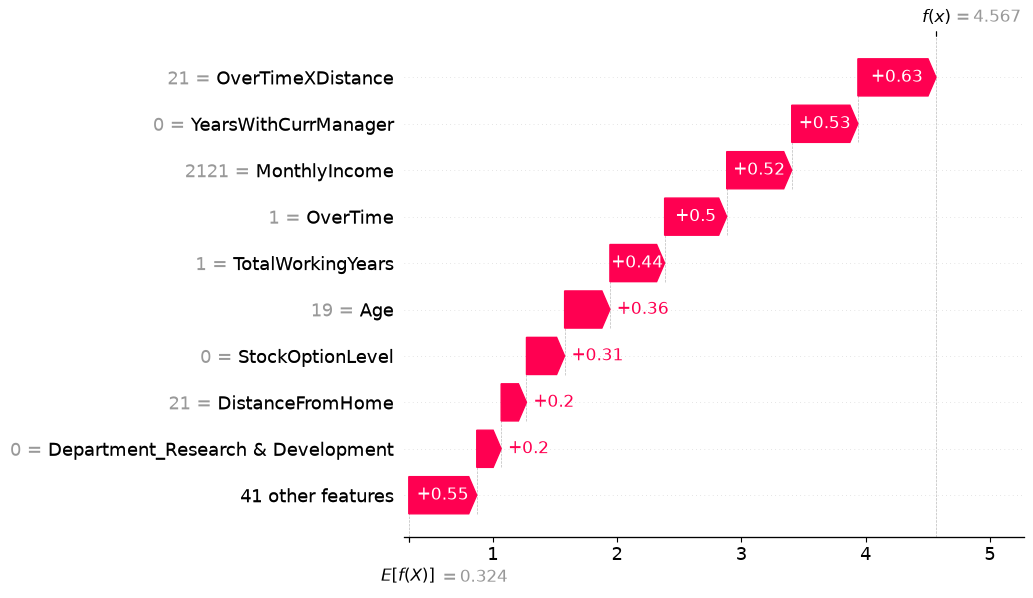

In [4]:
import numpy as np
i = int(np.argmax(model.predict_proba(X)[:, 1]))
print(f"แถว test #{i} | ลาออกจริง = {bool(y.iloc[i])}")
shap.plots.waterfall(exp[i], max_display=10)

In [5]:
top_factors(exp, i, n=5)

,feature,value,shap,direction
0,OverTimeXDistance,21.0,0.628538,เพิ่มความเสี่ยง
1,YearsWithCurrManager,0.0,0.532520,เพิ่มความเสี่ยง
2,MonthlyIncome,2121.0,0.523175,เพิ่มความเสี่ยง
3,OverTime,1.0,0.499410,เพิ่มความเสี่ยง
4,TotalWorkingYears,1.0,0.440410,เพิ่มความเสี่ยง


## 3. รายบุคคล: คนที่ลาออกจริงแต่โมเดลให้คะแนนต่ำ (โมเดลพลาด)

แถว test #240 | ลาออกจริง = True | คะแนนเสี่ยง = 0.04


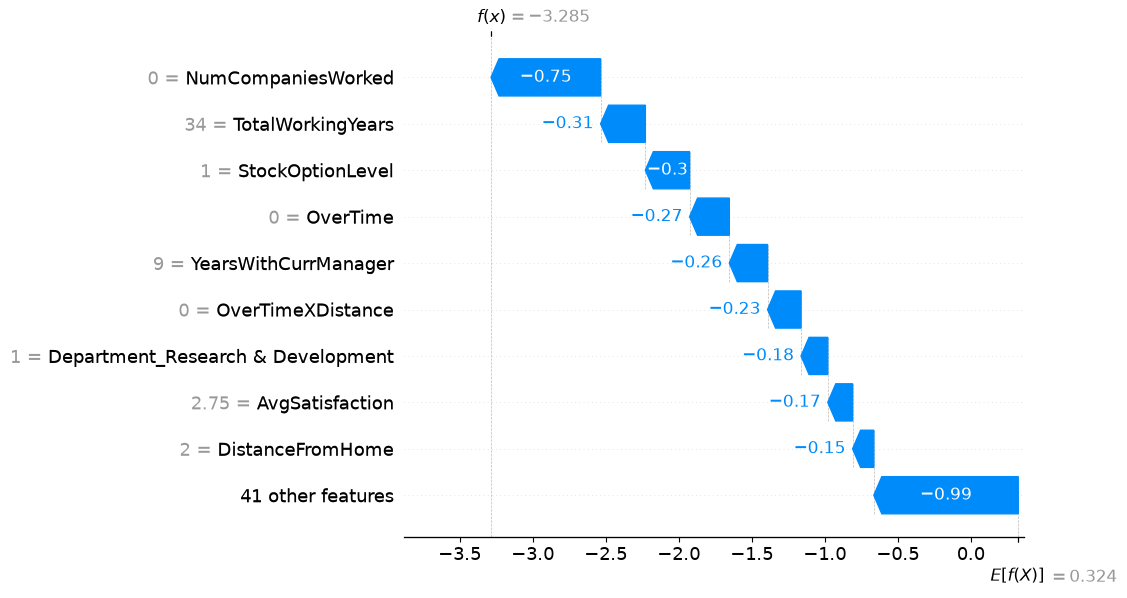

In [6]:
p = model.predict_proba(X)[:, 1]
j = int(np.argmin(np.where(y.values == 1, p, 9)))
print(f"แถว test #{j} | ลาออกจริง = {bool(y.iloc[j])} | คะแนนเสี่ยง = {p[j]:.2f}")
shap.plots.waterfall(exp[j], max_display=10)

## 4. ค่าเฉลี่ย |SHAP| ต่อฟีเจอร์ (เตรียมส่งต่อ Company Summary)

In [7]:
mean_abs_shap(exp).head(10).round(3)

OverTime                0.350
StockOptionLevel        0.350
NumCompaniesWorked      0.309
AvgSatisfaction         0.301
MonthlyIncome           0.289
OverTimeXDistance       0.274
Age                     0.258
YearsWithCurrManager    0.225
BusinessTravel          0.203
DailyRate               0.191
dtype: float32